Notebook for dealing with PL time series.

In [153]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm
import time

In [154]:
#Import/export functions: 
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=1000, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

In [155]:
#Starting timer for runtime 
start_time = time.time()

In [156]:
#Colourmap functions
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink

In [157]:
# Add plotting def here: 

def waterfall_plotting(x_raw, y_raw, n_files, time1, idx,  y_fit=None, filename="Filename Here.jpeg"):
    """
    Plots multiple spectral datasets (waterfall plot style) using a color gradient 
    based on the 'time1' array.

    Args:
        x_raw (list/array): A list/array of x-data (e.g., Wavelength). Should have n_files entries.
        y_raw (list/array): A list/array of y-data (e.g., Intensity). Should have n_files entries.
        n_files (int): The total number of files/datasets.
        time1 (array): The time associated with each file. Length must be n_files.
        y_fit (list/array, optional): Fitted y-data for each file. Defaults to None.
        c1, c2, get_color_gradient: Required for color generation (assumed to be available).
    """

    if get_color_gradient is None:
        raise NotImplementedError("The 'get_color_gradient' function must be provided or defined.")
        
    # Check that input data matches n_files
    if len(x_raw) != n_files or len(y_raw) != n_files or len(time1) != n_files:
        raise ValueError(f"Input data lengths (x_raw: {len(x_raw)}, y_raw: {len(y_raw)}, time1: {len(time1)}) must all equal n_files ({n_files}).")
    

    #Plotting params
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ax = plt.gca()# this outputs a 1x1 subplot - change if you want more/less rows or columns 

    # Margins and, line widths
    ax.tick_params(direction='in', length=6)
    ax.margins (0.5,0.5)
    ax.autoscale(enable=None, axis="x", tight=True)

    # Titles and labels
    plt.xlabel("Wavelength (nm)", size = 20)
    plt.ylabel("Intensity (a.u.)", fontsize=20)
    plt.title(f"Single Gaussian Fitting", size=20)
    ax.tick_params(axis='both', labelsize=20)
    
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis

    #Colormap calculation. 
    colors=get_color_gradient(c1,c2,n_files)

    if y_fit is not None: 
    
        plt.scatter(x_raw, y_raw, label=f"{t}s", color=colors[idx], s=10)
        plt.plot(x_raw, y_fit, label=f"_nolegend_", color=colors[idx], linewidth=2)
        plt.autoscale()
    else:
        plt.scatter(x_raw, y_raw, label=f"{t}s", color=colors[idx], s=10)
    

    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time1), vmax=np.max(time1))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=20)
    cbar.ax.tick_params(labelsize=20)
    plt.autoscale(enable=True, axis='y', tight=False)

    #Saving
    #fig=plt.gcf()
    #save_plot_to_folder(fig, save_path, filename)
    plt.show()

In [158]:
# Creating arrays for waterfall plots (every 10th file)
# Can edit this to remove n files if number of datapoints is consistenlty 100 for consistency but this is a good point to check number of files is equal to number of 
def waterfall_array(list, n_files):
    new_array = []
    #if len(list)==n_files: 
    #    raise ValueError(f"Input list length ({len(list)}) must equal n_files ({n_files}).")
    n=len(list)
    step = (n-1)//9
    selected_indices = [min(i*step, n-1) for i in range(10)]

    new_array = [list[i] for i in selected_indices]
    return new_array

In [159]:
def full_waterfall_arrays(x_data, y_data, n_files, y_fit = None): 
    if y_fit is not None: 
        x_data_new = waterfall_array(x_data, n_files)
        y_data_new = waterfall_array(y_data, n_files)
        y_fit_new = waterfall_array(y_fit, n_files)
        return x_data_new, y_data_new, y_fit_new

    else: 
        x_data_new = waterfall_array(x_data, n_files)
        y_data_new = waterfall_array(y_data, n_files)
        return x_data_new, y_data_new

In [160]:
#Spectra Fitting [Single Gaussian]:

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [169]:
# Gaussian fitting function using data from a dataset (i.e. from each individual file) 
def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - A_fit: Amplitude of the fitted Gaussian
    - mu_fit: Mean (center) of the fitted Gaussian
    - sigma_fit: Standard deviation (width) of the fitted Gaussian
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
       
        # Return the fitted parameters and covariance matrix
        return A_fit, mu_fit, sigma_fit, popt, pcov

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

In [177]:
#Fitting for single gaussian
def fit_gaussian_from_files(file_directory, rows, image_time, bckg, int_time):
    min_scatter=[]
    mean_scatter=[]
    max_scatter=[]
    time_scatter=[]
    gaussian_scatter=[]
    gaussian_min = []
    gaussian_max = []
    fwhm_scatter = []
    t=-int(image_time)
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ## this outputs a 1x1 subplot - change if you want more/less rows or columns ##
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=20)
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = 20)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", fontsize=20)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    
    # Loop through files in the specified directory
 #   for filename in os.listdir(file_directory):
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}")
        t += image_time
        time_scatter.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
        # Import bckg and adjust for bckg
        with open(bckg, 'r', encoding='utf-8', errors='replace') as f:
            bckg_data = np.loadtxt(f, skiprows=rows)
        x_bckg =bckg_data[:,0]
        y_bckg = bckg_data[:,1]
        y_data = np.subtract(y_data,y_bckg)
        adjustment = 10000/int_time
        y_data = [i*adjustment for i in y_data]
    
        # Fit the Gaussian curve to this dataset
        A, mu, sigma, popt, pcov= fit_gaussian_from_dataset(x_data, y_data)
        y_fit=gaussian(x_data,*popt)
        #for finding peak centre for fitted gaussian
        peak_index=np.argmax(y_fit)
        x_fit_max=x_data[peak_index]
        gaussian_scatter.append(x_fit_max)
        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm / 2
        x_right = highest['cen'] + fwhm / 2
        
        # Store in lists for output
        gaussian_min.append(x_left)
        gaussian_max.append(x_right)
        fwhm_scatter.append(fwhm)
        #Uncomment for debugging: 
        #print(f"Min:{min_scatter}\n Mean: {mean_scatter}\n Max: {max_scatter}")
        #print(time_scatter)
        # If fitting was successful, plot the result
        if A is not None:
            
            plt.scatter(x_data, y_data, label=f"{t}s", color=colors[idx], s=10)
            plt.plot(x_data, y_fit, label=f"_nolegend_", color=colors[idx], linewidth=2)
            plt.title(f"Single Gaussian Fitting", size=20)
            plt.xlabel("Wavelength (nm)", size=20)
            plt.ylabel("Intensity", size=20)
            plt.autoscale()
            #plt.legend()
                
    print("All gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time_scatter), vmax=np.max(time_scatter))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=20)
    cbar.ax.tick_params(labelsize=20)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Comment out if no file saving required
    fig=plt.gcf()
    save_plot_to_folder(fig, save_path, filename='PL_singlegaussian.jpeg')
    return min_scatter, mean_scatter, max_scatter, time_scatter, gaussian_scatter, fwhm_scatter
    plt.show() #Keep after saving figure due to errors.

#Fitting for single gaussian
def fit_gaussian_from_files(file_directory, rows, image_time, bckg, int_time):
    peaks=[]
    time1=[]
    fwhm=[]
    #Min/Max from FWHM of fits
    min_fit = []
    max_fit = []
    t=-int(image_time)

    #Sorting files in numerical for plotting 
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)

    
    # Loop through files in the specified directory
     #for filename in os.listdir(file_directory):
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
        file_path = os.path.join(file_directory, filename)
        #print(f"\nProcessing file: {filename}")
        t += image_time
        time1.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)
        
        x_data = data[:, 0]
        y_data = data[:, 1]
        
        # Import bckg and adjust for bckg
        with open(bckg, 'r', encoding='utf-8', errors='replace') as f:
            bckg_data = np.loadtxt(f, skiprows=rows)
        #Background subtraction: 
        x_bckg = bckg_data[:,0]
        y_bckg = bckg_data[:,1]
        y_data = np.subtract(y_data,y_bckg)
        bckg_correction = 10000/int_time
        y_data = [i*bckg_correction for i in y_data]
    
        # Fit the Gaussian curve to this dataset
        A, mu, sigma, popt, pcov = fit_gaussian_from_dataset(x_data, y_data)
        y_fit=gaussian(x_data,*popt)
        #for finding peak centre for fitted gaussian
        peak_index=np.argmax(y_fit)
        x_fit_max=x_data[peak_index]
        peaks.append(x_fit_max)
        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm_initial = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm_initial / 2
        x_right = highest['cen'] + fwhm_initial / 2
        
        # Store in lists for output
        min_fit.append(x_left)
        max_fit.append(x_right)
        fwhm.append(fwhm_initial)
        # Checks for lengths:
        #print(f"x length = {len(x_data)}")
        #print(f"y length = {len(y_data)}")
        #print(f"y length = {len(y_fit)}")
        #Uncomment for debugging: 
        #print(f"Min:{min_scatter}\n Mean: {mean_scatter}\n Max: {max_scatter}")
        #print(time_scatter)
        #print(f"fwhm length:{len(fwhm)}")
        # If fitting was successful, plot the result
        #if A is not None:
            #print("All gaussians processed. Congrats!")

    return time1, peaks, min_fit, max_fit, fwhm, x_data, y_data, n_files, idx



In [178]:
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y


In [179]:
# Estimating guesses from data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    
    # 1. Capture both the peaks (indices) and the properties in the FIRST call
    peaks, properties = find_peaks(y_smooth, prominence=prominence, distance=distance)

    # Sort peaks by height (amplitude) and limit to top 2 (can be changed depending on spectra properties)
    if len(peaks) > 2:
        # 2. Use the already defined 'properties' variable
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices] # Update peaks to only include the top 2

    # The rest of the function proceeds only with the 1 or 2 highest peaks
    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]

    return guess, len(peaks)

In [180]:
#MultiGaussianFits:

# Auto-generate initial guess based on data
#def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
#    y_smooth = gaussian_filter1d(y, sigma=2)
#    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
#    
#    # Sort peaks by height (amplitude) and limit to top 2
#    if len(peaks) > 2:
#        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
#        peaks = peaks[sorted_indices]

#    guess = []
#    for i in peaks:
#        amp = y[i]
#        cen = x[i]
#        wid = 0.001 # Adjust based on data
#        guess += [amp, cen, wid]
#    
#    return guess, len(peaks)


#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_directory, rows, image_time, bckg, int_time):
    time1=[]
    peaks=[]
    min_fit= []
    max_fit = []
    fwhm = []
   
    t=-int(image_time)
    #Plotting parameters
    fig, ax = plt.subplots(1,1, sharey = True, figsize = (10, 8))
    plt.rcParams.update({'font.size': 30})
    ax = plt.gca()
    ax.tick_params(direction='in', length=6)
    ax.tick_params(axis='both', labelsize=20)
    ax.margins (0.5,0.5)
    plt.xlabel("SPV (V)", size = 20)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)", size=20)
    files=sorted([f for f in os.listdir(file_directory) if f.endswith('.txt')])
    n_files=len(files)
    colors=get_color_gradient(c1,c2,n_files)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    for idx, filename in enumerate(tqdm(files, desc="Processing files")):
    
        file_path = os.path.join(file_directory, filename)
        print(f"\nProcessing file: {filename}") #Use if you want each individual file processed
        t += image_time
        time1.append(t)

        with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
            data = np.loadtxt(f, skiprows=rows)

        x_data = data[:, 0]
        y_data = data[:, 1]
        # Import bckg and adjust for bckg
        with open(bckg, 'r', encoding='utf-8', errors='replace') as f:
            bckg_data = np.loadtxt(f, skiprows=rows)
        x_bckg =bckg_data[:,0]
        y_bckg = bckg_data[:,1]
        y_data = np.subtract(y_data,y_bckg)
        adjustment =int(10000/int_time)
        y_data = [i*adjustment for i in y_data]
        
        # Estimate initial guess and peak count
        initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)

        #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
        popt, _ = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        y_fit=multi_gaussian(x_data,*popt)
        peak_index_max=np.argmax(y_fit)
        x_peak_centre=x_data[peak_index_max]
        peaks.append(x_peak_centre)

        #For finding min and max *i.e. either side of the peaks. 
        # Extract Gaussian parameters
        gaussians = []
        for i in range(len(popt) // 3):
            amp = popt[i*3]
            cen = popt[i*3+1]
            wid = abs(popt[i*3+2])
            gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})

        # Identify the highest peak
        #highest = max(gaussians, key=lambda g: g['amp'])
        highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
        # FWHM = 2.355 * sigma
        fwhm_initial = 2.355 * highest['wid']
        x_left = highest['cen'] - fwhm_initial / 2
        x_right = highest['cen'] + fwhm_initial / 2

        # Store in lists for output
        min_fit.append(x_left)
        max_fit.append(x_right)
        # Optional: print for debugging
        #print(f"  Highest Peak at x = {highest['cen']:.4f}")
        #print(f"  FWHM = {fwhm:.4f} → Bounds: [{x_left:.4f}, {x_right:.4f}]")
        
        if n_peaks is not None:
            # Plot
            plt.scatter(x_data, y_data, label=f"{t}s",color=colors[idx], s=10)
            plt.plot(x_data, multi_gaussian(x_data, *popt), label=f"_nolegend_", color=colors[idx],linewidth=2)
            plt.title(f"Multi-Gaussian Fitting", size=20)
            plt.xlabel("SPV(V)", size=20)
            plt.ylabel("Distribution $V^{-1}$", size=20)
            plt.autoscale()
        #plt.legend()
        #plt.tight_layout()
            #plt.show()
    print("All multi gaussians processed. Congrats!")
    # Add the colorbar after plotting
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm = mcolors.Normalize(vmin=np.min(time1), vmax=np.max(time1))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.tight_layout()
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
    cbar.set_label('Time (s)', size=20)
    cbar.ax.tick_params(labelsize=20)
    plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
 #   fig=plt.gcf()
  #  save_plot_to_folder(fig,save_path,filename='MultiGaussian_Histogram.jpeg')
    return time1, peaks, min_fit, max_fit, fwhm, x_data, y_data, n_files, idx
    plt.show()    

In [181]:
#Input folders/files and file saving  
root = tk.Tk()
root.withdraw()
print("If pop up box not seen minimise spyder and select folder wanted for analysis")
folder_path1 = filedialog.askdirectory(title='Select input folder: Unpassivated')
bckg1 = filedialog.askopenfilename(title='Select bckg .txt file: Unpassivated')#,filetypes = ["*.txt"])
folder_path2 = filedialog.askdirectory(title='Select input folder: Passivated')
bckg2 = filedialog.askopenfilename(title='Select bckg .txt file: Passivated')#,filetypes = ["*.txt"])
save_path = filedialog.askdirectory(title='Select Folder to Save Plot')

If pop up box not seen minimise spyder and select folder wanted for analysis


In [182]:
#Selecting rows/integration time for unpassivated (1) and passivated (2), adjust accordingly 
#For skipping rows, note this should also skip enough to cut laser peak off. 
rows1 = 446
rows2 = 750
int_time1 = 25 
int_time2 = 300

image_time= 85 #seconds

Processing files: 100%|██████████| 100/100 [00:05<00:00, 19.77it/s]


All gaussians processed. Congrats!
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/6 - PL/251006_PLTimeSeries/RG0091_AEAPTMS\PL_singlegaussian.jpeg


Processing files: 100%|██████████| 100/100 [00:04<00:00, 20.30it/s]


All gaussians processed. Congrats!
Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/Lab Data/Processed Data/25_03_12_FACs_HK_Batch1/6 - PL/251006_PLTimeSeries/RG0091_AEAPTMS\PL_singlegaussian.jpeg


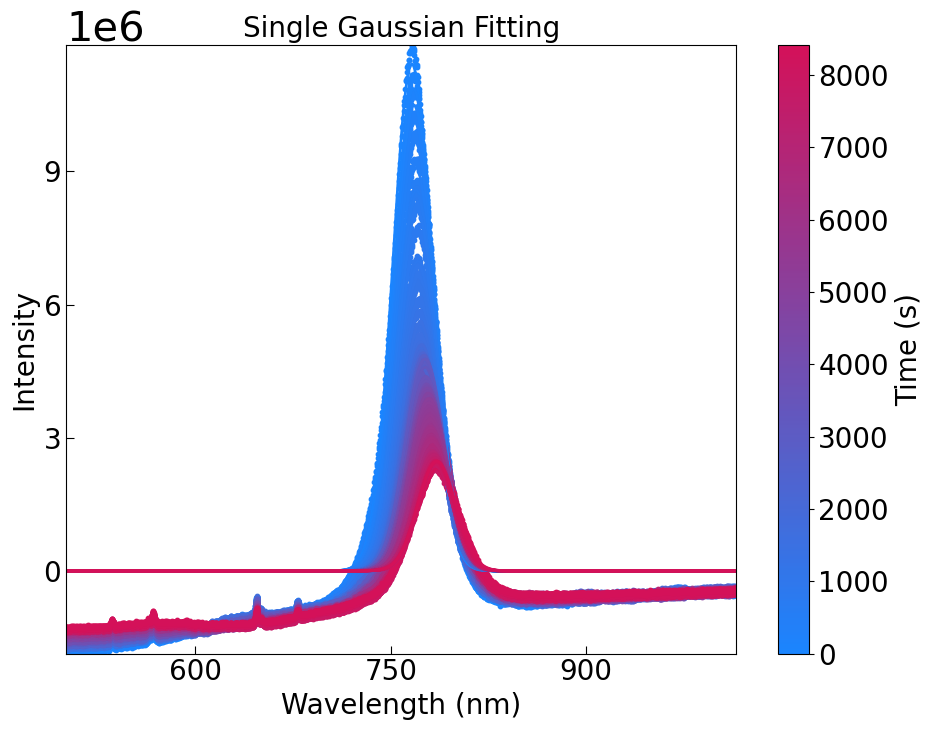

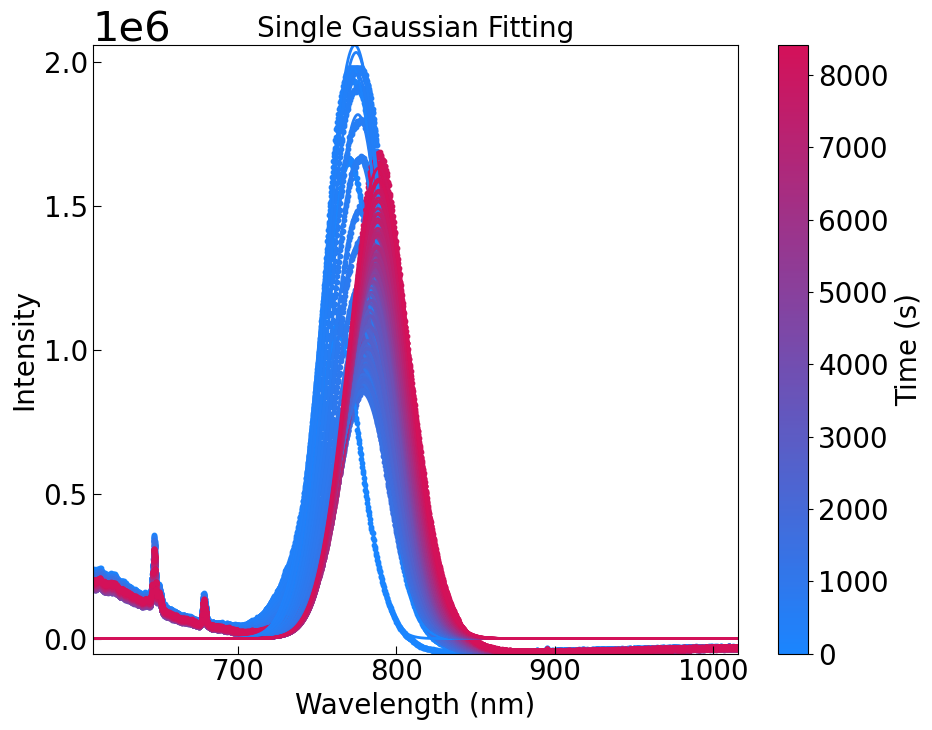

In [183]:
#Calling functions for constants: 
#time1, peaks1, min_fit1, max_fit1, fwhm1, x_data1, y_data1, n_files1, idx1=fit_gaussian_from_files(folder_path1,rows1,image_time, bckg1, int_time1)
#time2, peaks2, min_fit2, max_fit2, fwhm2, x_data2, y_data2, n_files2, idx2=fit_gaussian_from_files(folder_path2,rows2,image_time, bckg2, int_time2)

#Get smaller dataset for waterfall plots: 
#Unpassivated: 
#short_x1, short_y1, short_fit1 = full_waterfall_arrays(x_data1, y_data1, n_files1, peaks1)

#Passivated 
#short_x2, short_y2, short_fit2 = full_waterfall_arrays(x_data2, y_data2, n_files2, peaks2)


#Call for plotting full: 
#Unpassivated
#waterfall_plotting(x_data1, y_data1, n_files1, time1, idx1, peaks1, filename="Unpassivated_Full_Waterfall.jpeg")
#Passivated
#waterfall_plotting(x_data2, y_data2, n_files2, time2, idx2, peaks2,  filename="Passivated_Full_Waterfall.jpeg")


#Call for plotting clear waterfalls: 
#shortlen1 = len(short_x1)
#shortlen2 = len(short_x2)
#Unpassivated
#waterfall_plotting(short_x1, short_y1, shortlen1, time1, idx1, short_fit1, filename="Unpassivated_Short_Waterfall.jpeg")
#Passivated
#waterfall_plotting(x_data2, y_data2, shortlen2, time2, idx2, short_fit2, filename="Passivated_Short_Waterfall.jpeg")

min1,mean1,max1,time1, gaussian_scatter1, gauss_fwhm1=fit_gaussian_from_files(folder_path1,rows1,image_time, bckg1, int_time1)
min2,mean2,max2,time2, gaussian_scatter2, gauss_fwhm2=fit_gaussian_from_files(folder_path2,rows2,image_time, bckg2, int_time2)
